In [1]:
import numpy as np
import pandas as pd

# Import the dataset
df = pd.read_csv("ToyotaCorolla.csv")
df

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,1,0,0,0,1,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,1,0,1,0,0,0,1,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,0,1,0,0,0,1,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,0,1,0,0,0,1,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,1,0,1,1,1,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,0,1,0,0,1,1,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,0,1,0,0,0,1,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,0,1,0,0,0


In [2]:
df = df.select_dtypes(include=[np.number])

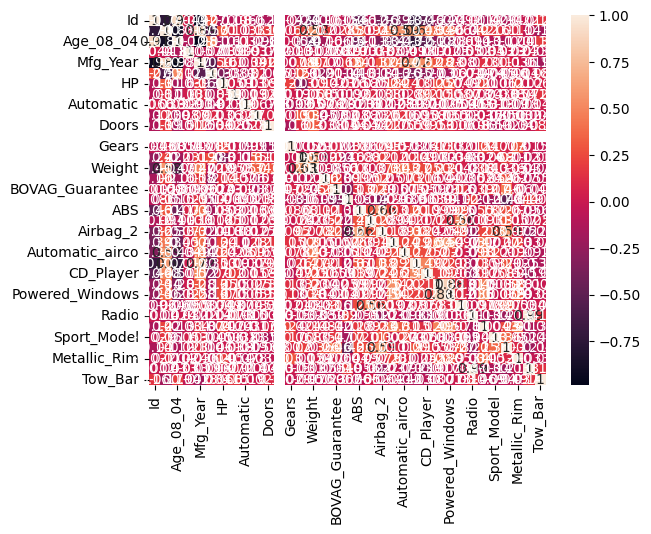

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True)
plt.show()

In [4]:
highly_correlated_pairs = np.where(np.abs(df.corr()) > 0.8)

In [5]:
for i, j in zip(highly_correlated_pairs[0], highly_correlated_pairs[1]):
    if i != j and i < j:
        print(f"Highly Correlated Pair: {df.columns[i]} and {df.columns[j]}")

Highly Correlated Pair: Id and Age_08_04
Highly Correlated Pair: Id and Mfg_Year
Highly Correlated Pair: Price and Age_08_04
Highly Correlated Pair: Price and Mfg_Year
Highly Correlated Pair: Age_08_04 and Mfg_Year
Highly Correlated Pair: Central_Lock and Powered_Windows
Highly Correlated Pair: Radio and Radio_cassette


In [6]:
df.drop(['Id', 'Age_08_04', 'Central_Lock', 'Radio'], axis=1, inplace=True)

In [7]:
#Spliting Variables
Y = df['Price']
X = df.drop('Price', axis=1)

In [8]:
#test and Train Data Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

In [9]:
#fitting model
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train, Y_train)

LinearRegression()

In [10]:
Y_pred = LR.predict(X_test)

In [11]:
#metrices
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error:", mse.round(3))
print("Root Mean Squared Error:", np.sqrt(mse).round(3))
print("R squared:", r2_score(Y_test, Y_pred).round(3))

Mean Squared Error: 2145808.197
Root Mean Squared Error: 1464.858
R squared: 0.81


In [12]:
#vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [13]:
final_model_vif_result = calculate_vif(X_train)
print("VIF Values for the Final Model:")
print(final_model_vif_result)

VIF Values for the Final Model:
            Variable           VIF
0          Mfg_Month  1.125462e+00
1           Mfg_Year  5.157787e+00
2                 KM  2.116816e+00
3                 HP  1.761203e+00
4          Met_Color  1.123233e+00
5          Automatic  1.111038e+00
6                 cc  3.100184e+00
7              Doors  1.304438e+00
8          Cylinders  8.180452e+06
9              Gears  1.297504e+00
10     Quarterly_Tax  3.683619e+00
11            Weight  4.451396e+00
12     Mfr_Guarantee  1.180402e+00
13   BOVAG_Guarantee  1.356932e+00
14  Guarantee_Period  1.566960e+00
15               ABS  2.226560e+00
16          Airbag_1  1.485250e+00
17          Airbag_2  3.027029e+00
18             Airco  1.841907e+00
19   Automatic_airco  1.799715e+00
20     Boardcomputer  2.658136e+00
21         CD_Player  1.532931e+00
22   Powered_Windows  1.724518e+00
23    Power_Steering  1.454031e+00
24         Mistlamps  2.107776e+00
25       Sport_Model  1.481151e+00
26  Backseat_Divider  2

In [14]:
#model validation
import statsmodels.api as sm
X_train_with_constant = sm.add_constant(X_train)
model = sm.OLS(Y_train, X_train_with_constant).fit()

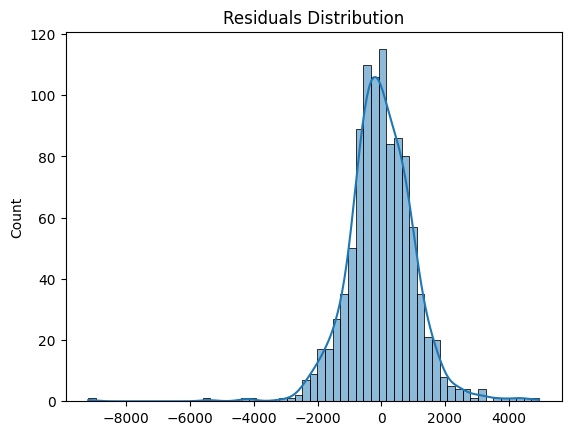

In [15]:
#residual Analysis
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

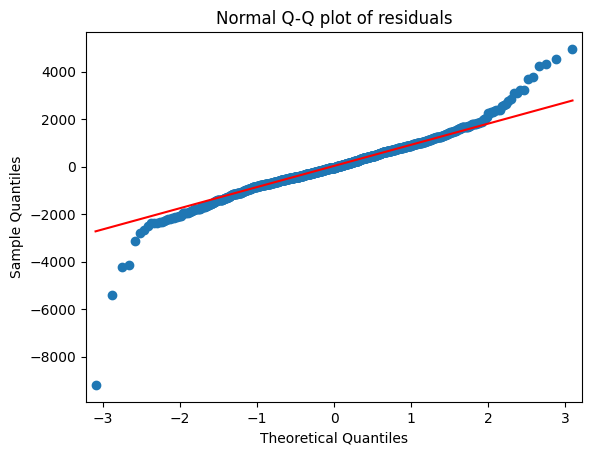

In [16]:
#qq-plot
qqplot = sm.qqplot(residuals, line='q')
plt.title("Normal Q-Q plot of residuals")
plt.show()

In [17]:
#cook distance
influence = model.get_influence()
cooks_distance = influence.cooks_distance[0]

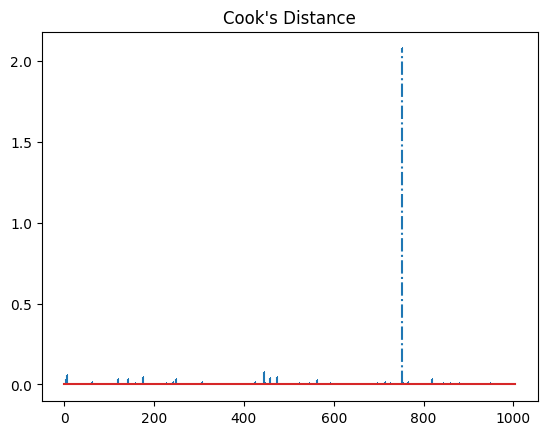

In [18]:
plt.stem(np.arange(len(cooks_distance)), cooks_distance, markerfmt=",", linefmt="-.")
plt.title("Cook's Distance")
plt.show()


In [19]:
#leverage Cutoff
leverage_cutoff = 2 * (X_train_with_constant.shape[1] + 1) / X_train_with_constant.shape[0]
print("Leverage Cutoff:", leverage_cutoff)

Leverage Cutoff: 0.061691542288557215


In [20]:
high_leverage_points = np.where(influence.hat_matrix_diag > leverage_cutoff)[0]
print("High Leverage Points:", high_leverage_points)

High Leverage Points: [ 36  61  62  70  81  93 119 141 161 168 209 221 225 227 241 277 307 320
 341 409 411 412 424 441 445 455 458 462 473 481 498 522 532 536 546 592
 603 619 632 641 671 675 681 718 739 743 753 795 808 819 826 835 837 852
 873 875 900 911 919 946 980 993 995]


In [21]:
indices_to_drop = X_train.index[high_leverage_points].tolist()
X_train_cleaned = X_train.drop(index=indices_to_drop).reset_index(drop=True)
Y_train_cleaned = Y_train.drop(index=indices_to_drop).reset_index(drop=True)

In [22]:
#spliting Data Again with cleaned Data
X_train_cleaned, X_test_cleaned, Y_train_cleaned, Y_test_cleaned = train_test_split(X_train_cleaned, Y_train_cleaned, test_size=0.3, random_state=0)

In [23]:
#fitting model
X_train_cleaned_with_constant = sm.add_constant(X_train_cleaned)
model_cleaned = sm.OLS(Y_train_cleaned, X_train_cleaned_with_constant).fit()

In [24]:
X_test_cleaned_with_constant = sm.add_constant(X_test_cleaned)
Y_pred_cleaned = model_cleaned.predict(X_test_cleaned_with_constant)

In [25]:
#metrices
mse_cleaned = mean_squared_error(Y_test_cleaned, Y_pred_cleaned)
print("Mean Squared Error (Cleaned Model):", mse_cleaned.round(3))
print("Root Mean Squared Error (Cleaned Model):", np.sqrt(mse_cleaned).round(3))
print("R squared (Cleaned Model):", r2_score(Y_test_cleaned, Y_pred_cleaned).round(3))

Mean Squared Error (Cleaned Model): 958270.331
Root Mean Squared Error (Cleaned Model): 978.913
R squared (Cleaned Model): 0.929
